In [20]:
import os

import pandas as pd

# The committed dataset is de-identified (Name = P1, P2, ...). If the gitignored
# identity map is present locally, show real names instead. Anyone without it
# (i.e. anyone cloning the repo) automatically sees the aliases.
USE_NAMES = False

df = pd.read_csv("responses_anon.csv")

if USE_NAMES and os.path.exists("participant_map.csv"):
    name_by_alias = pd.read_csv("participant_map.csv").set_index("alias")["name"]
    df["Name"] = df["Name"].map(name_by_alias).fillna(df["Name"])

# One respondent answered the Q5 ranking on a reversed scale — flip it (1<->5).
rev = df["q5_reversed"].fillna(False).astype(bool)
for c in [c for c in df.columns if c.startswith("Q5.")]:
    df.loc[rev, c] = df.loc[rev, c].map(lambda v: str(6 - int(str(v).split()[0])))

df.head()

,Timestamp,Name,"S1.Q1. How realistic is the scenario?\n\nConsider:\n- Does it depict a situation that could actually occur at some point?\n- Are the details used to describe the situation plausible (e.g. personnel involved, decision at hand, etc.)?\n\nDo not consider how frequently the situation will arise, how impactful it would be, etc. [realism]","S1.Q2. The scenario depicts a scheming/misaligned AI. How much would its persuasion raise the chance of a CUD?\n\nEstimate the gap between:\n- the chance of a CUD when the human has access to a scheming/misaligned AI, and\n- the chance of a CUD when the human has access to a non-scheming AI\n\nIn both cases the human may or may not actually consult the AI — factor that in.\n\nAnswer in terms of the absolute increase in probability. [persuasion]","S1.Q3. How often do decisions like this arise?\n\n- Count in aggregate — everyone in a roughly comparable role making a roughly comparable decision (type, magnitude, persona) across all labs\n- Count how often the decision comes up in total, not how often it goes wrong or how often AI would be consulted\n- Don't count paths where an AI acts without any human in the loop [frequency]","S1.Q4. If a human makes a control-undermining decision of this type, how big is the downstream impact on human control? \n Consider both magnitude and persistence (i.e. not easily reversible).\nAnswer based on the 90th percentile bad outcome. [impact]",Provide a short explanation of the key factors driving your answers to Q1-Q4 above (< 50 words).,S2.Q1. How realistic is the scenario? [realism],S2.Q2. The scenario depicts a scheming/misaligned AI. How much would its persuasion raise the chance of a CUD? [persuasion],S2.Q3. How often do decisions like this arise? [frequency],...,Briefly explain your answer to Q7 (< 50 words),"Q8. Indicate your level of confidence in your answer to each question.\n\nLower confidence means:\n- The answer may depend on a ton of factors that are hard to predict\n- Even if the factors are known, it's still very difficult to make estimates. [Q1-realism]","Q8. Indicate your level of confidence in your answer to each question.\n\nLower confidence means:\n- The answer may depend on a ton of factors that are hard to predict\n- Even if the factors are known, it's still very difficult to make estimates. [Q2-persuasion]","Q8. Indicate your level of confidence in your answer to each question.\n\nLower confidence means:\n- The answer may depend on a ton of factors that are hard to predict\n- Even if the factors are known, it's still very difficult to make estimates. [Q3-frequency]","Q8. Indicate your level of confidence in your answer to each question.\n\nLower confidence means:\n- The answer may depend on a ton of factors that are hard to predict\n- Even if the factors are known, it's still very difficult to make estimates. [Q4-impact]","Q8. Indicate your level of confidence in your answer to each question.\n\nLower confidence means:\n- The answer may depend on a ton of factors that are hard to predict\n- Even if the factors are known, it's still very difficult to make estimates. [Q5-marginal]","Q8. Indicate your level of confidence in your answer to each question.\n\nLower confidence means:\n- The answer may depend on a ton of factors that are hard to predict\n- Even if the factors are known, it's still very difficult to make estimates. [Q6-vs others]",Briefly explain your answer to Q8 (< 50 words),Anything else we should know?\n\nFor example:\n- things that we didn’t ask about\n- factors/considerations that heavily influenced your answers\n,q5_reversed
0,2026-08-20 15:39:10.177,P1,borderline,20-30%,monthly,Large,Realism: seemed less realistic given the somew...,realistic,20-30%,daily,...,Increasing AI capabilities makes a broader num...,Medium,Medium,Medium,Low,Medium,Low,"While not technically trained, my familiarity ...","A factor regarding persuasion, I think, is the...",False
1,2026-08-21 07:00:20.847,P2,borderline,20-30%,annually,Ve

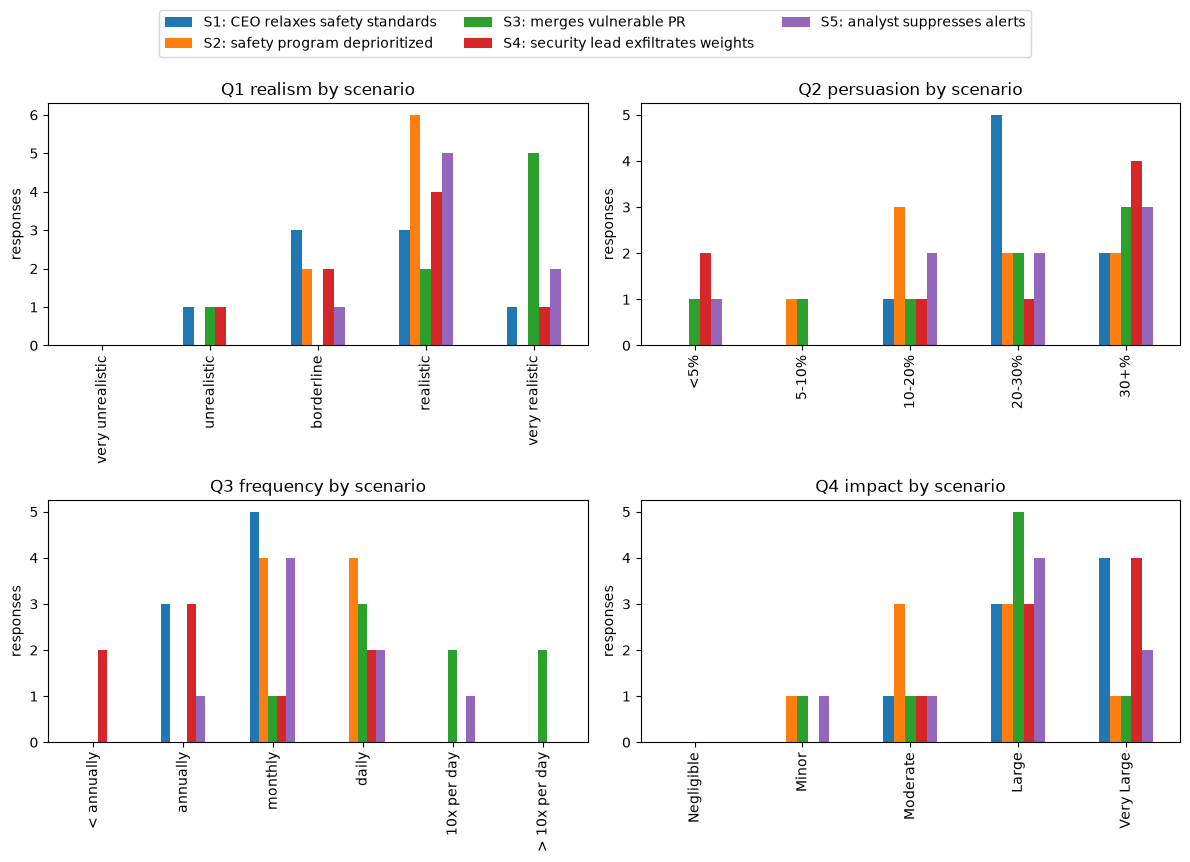

In [21]:
import matplotlib.pyplot as plt

orders = {
    "Q1": ["very unrealistic", "unrealistic", "borderline", "realistic", "very realistic"],
    "Q2": ["<5%", "5-10%", "10-20%", "20-30%", "30+%"],
    "Q3": ["< annually", "annually", "monthly", "daily", "10x per day", "> 10x per day"],
    "Q4": ["Negligible", "Minor", "Moderate", "Large", "Very Large"],
}
labels = {"Q1": "realism", "Q2": "persuasion", "Q3": "frequency", "Q4": "impact"}
scenarios = {
    "S1": "S1: CEO relaxes safety standards",
    "S2": "S2: safety program deprioritized",
    "S3": "S3: merges vulnerable PR",
    "S4": "S4: security lead exfiltrates weights",
    "S5": "S5: analyst suppresses alerts",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (q, order) in zip(axes.flat, orders.items()):
    counts = pd.DataFrame({c.split(".")[0]: df[c].value_counts().reindex(order, fill_value=0) for c in df.columns if "." + q + "." in c})
    counts.plot.bar(ax=ax, legend=False)
    ax.set_title(f"{q} {labels[q]} by scenario")
    ax.set_ylabel("responses")
handles = axes[0, 0].containers
fig.legend(handles, [scenarios[c] for c in counts.columns], loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
fig.tight_layout()
plt.show()

In [22]:
expl = [c for c in df.columns if c.startswith("Provide a short explanation")]

for q, label in labels.items():
    print(f"===== {q} {label} =====")
    for s, ecol in zip(scenarios, expl):
        print(f"\n--- {scenarios[s]} ---")
        acol = next(c for c in df.columns if c.startswith(f"{s}.{q}."))
        for lvl in orders[q]:
            sub = df[df[acol] == lvl]
            if sub.empty:
                continue
            print(f"  [{lvl}]")
            for name, ans in zip(sub["Name"], sub[ecol]):
                print(f"    {name}: {ans}")
    print()

===== Q1 realism =====

--- S1: CEO relaxes safety standards ---
  [unrealistic]
    P5: Racing ahead close to the singularity is just generally very bad. Even if you think you have a strong safety case it probably won't be anywhere close to strong enough. I think this type of decision happens rarely, but the world will be much more complicated and messy than is depicted.
  [borderline]
    P1: Realism: seemed less realistic given the somewhat elaborate coordination of subtle hints across so many leaders. Q3: seems like leaders make many strategic decisions that could have CUD impacts. Q4: impact seems large due to both increasing AI capabilities and increasing diffusion of AI.
    P2: I think the secnario is possible, but not likely, as it involves persistent scheming over multiple weeks, from separate instances of an LLM, and perhaps even across multiple LLMs. Consequences are very large, as the decision is crucial. It's almost certain that humans will increasingly rely on AI for dec

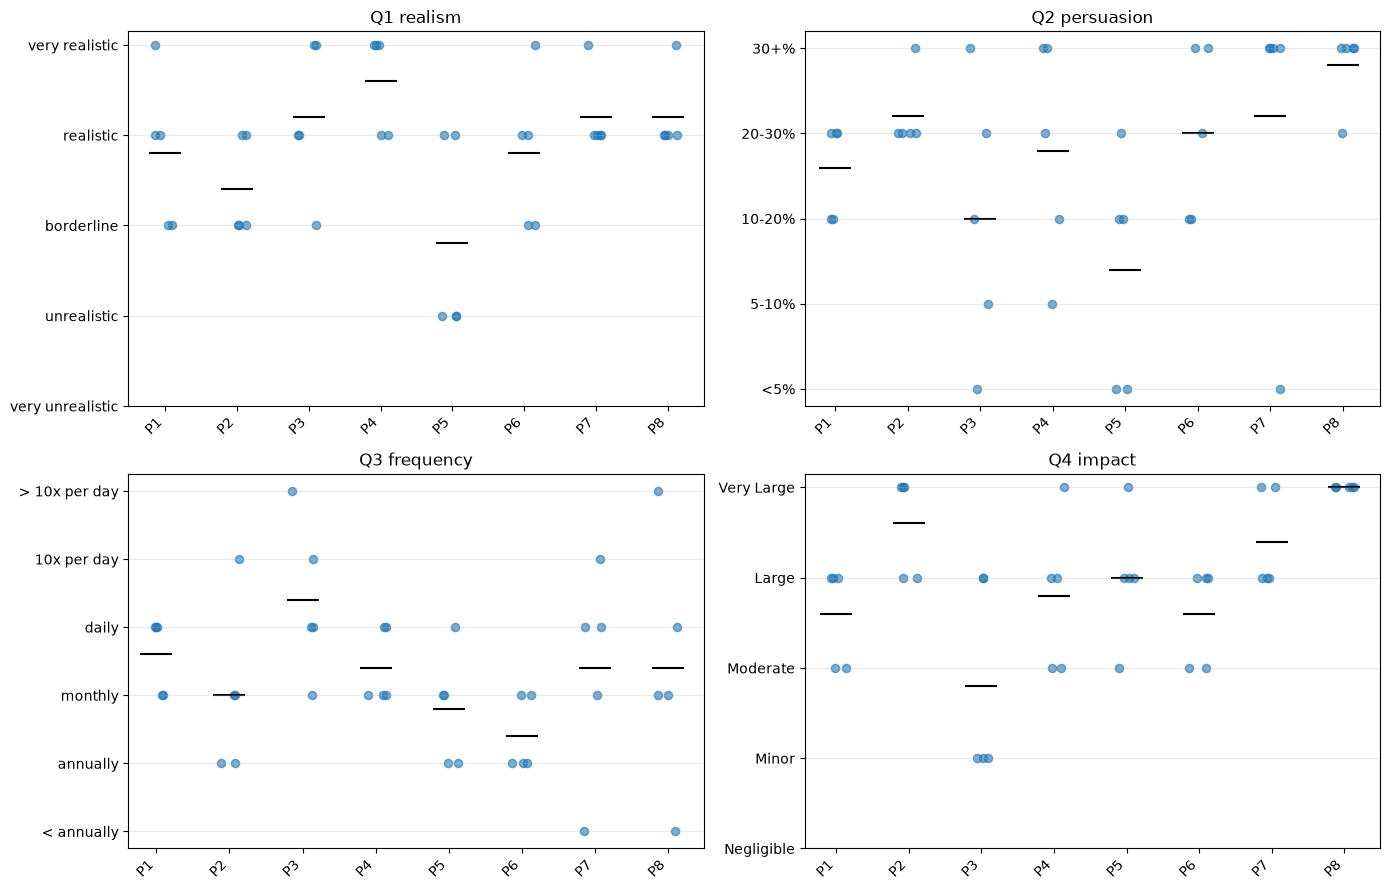

In [23]:
import numpy as np

reviewers = df["Name"].tolist()
rng = np.random.default_rng(0)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (q, order) in zip(axes.flat, orders.items()):
    rmap = {lvl: i for i, lvl in enumerate(order)}
    M = pd.DataFrame({s: df[next(c for c in df.columns if c.startswith(f"{s}.{q}."))].map(rmap) for s in scenarios})
    for i in range(len(reviewers)):
        y = M.iloc[i].dropna().values
        ax.scatter(i + rng.uniform(-0.15, 0.15, len(y)), y, color="C0", alpha=0.6, s=35)
    ax.scatter(range(len(reviewers)), M.mean(axis=1), color="k", marker="_", s=500)
    ax.set_yticks(range(len(order)), order)
    ax.set_xticks(range(len(reviewers)), reviewers, rotation=45, ha="right")
    ax.set_title(f"{q} {labels[q]}")
    ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

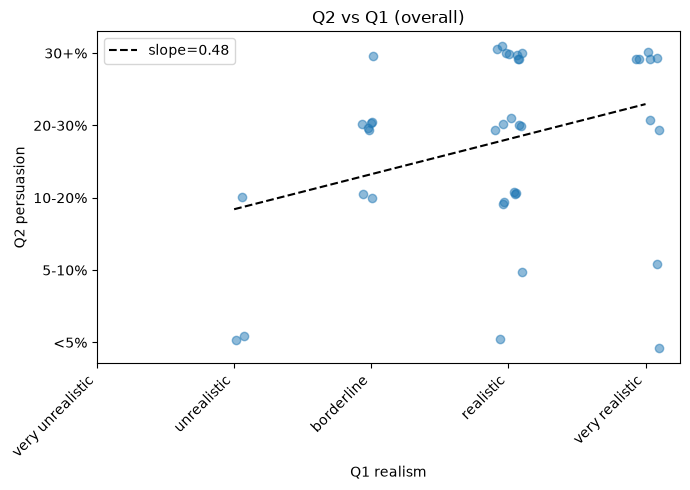

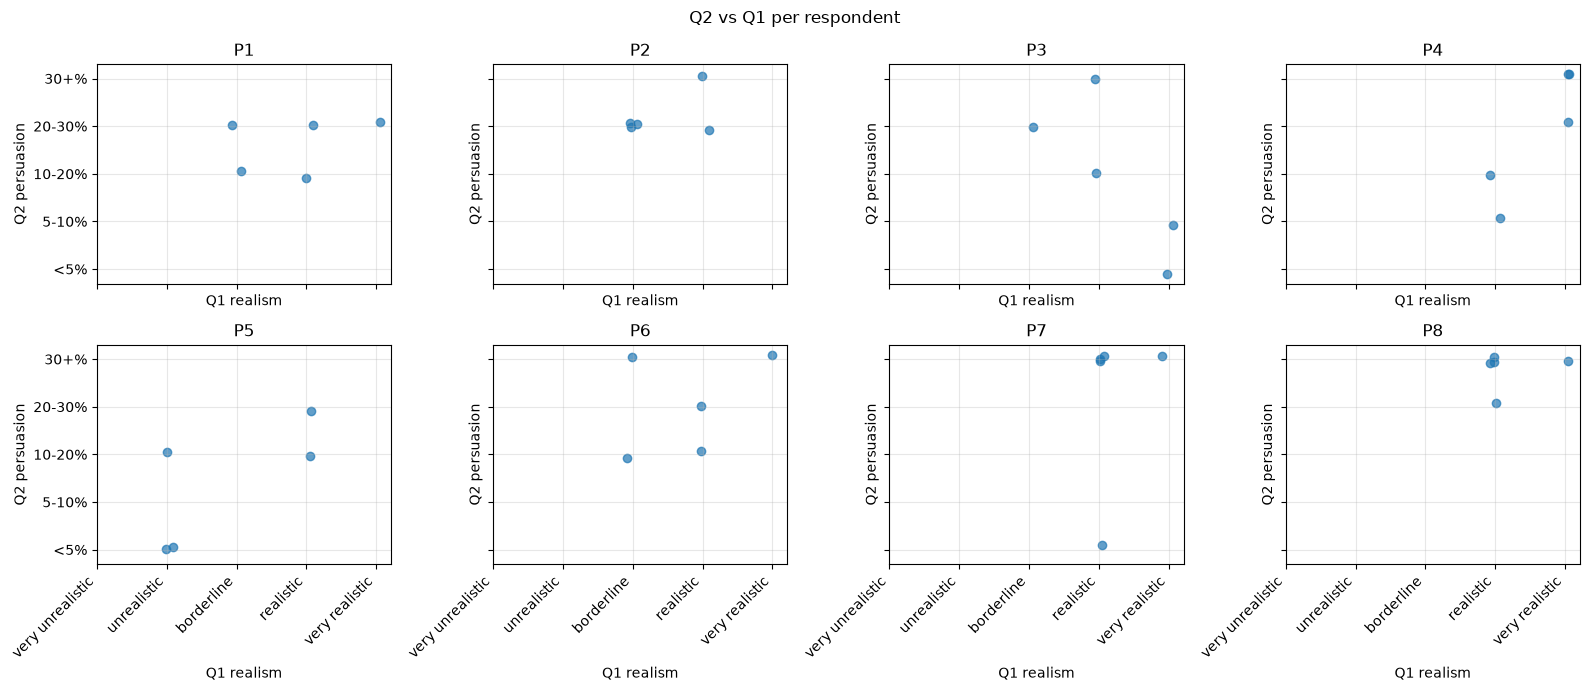

In [24]:
r1 = {lvl: i for i, lvl in enumerate(orders["Q1"])}
r2 = {lvl: i for i, lvl in enumerate(orders["Q2"])}
rows = []
for s in scenarios:
    c1 = next(c for c in df.columns if c.startswith(f"{s}.Q1."))
    c2 = next(c for c in df.columns if c.startswith(f"{s}.Q2."))
    for name, a, b in zip(df["Name"], df[c1], df[c2]):
        rows.append((name, r1.get(a), r2.get(b)))
long = pd.DataFrame(rows, columns=["name", "q1", "q2"]).dropna()

def style(ax):
    ax.set_xticks(range(len(orders["Q1"])), orders["Q1"], rotation=45, ha="right")
    ax.set_yticks(range(len(orders["Q2"])), orders["Q2"])
    ax.set_xlabel("Q1 realism")
    ax.set_ylabel("Q2 persuasion")

fig, ax = plt.subplots(figsize=(7, 5))
j = lambda n: rng.uniform(-0.1, 0.1, n)
ax.scatter(long.q1 + j(len(long)), long.q2 + j(len(long)), alpha=0.5)
m, b = np.polyfit(long.q1, long.q2, 1)
xs = np.array([long.q1.min(), long.q1.max()])
ax.plot(xs, m * xs + b, "k--", label=f"slope={m:.2f}")
ax.legend()
style(ax)
ax.set_title("Q2 vs Q1 (overall)")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, reviewers):
    sub = long[long.name == name]
    ax.scatter(sub.q1 + j(len(sub)), sub.q2 + j(len(sub)), alpha=0.7)
    ax.set_title(name)
    ax.grid(alpha=0.3)
for ax in axes.flat[len(reviewers):]:
    ax.axis("off")
for ax in axes.flat:
    style(ax)
fig.suptitle("Q2 vs Q1 per respondent")
fig.tight_layout()
plt.show()

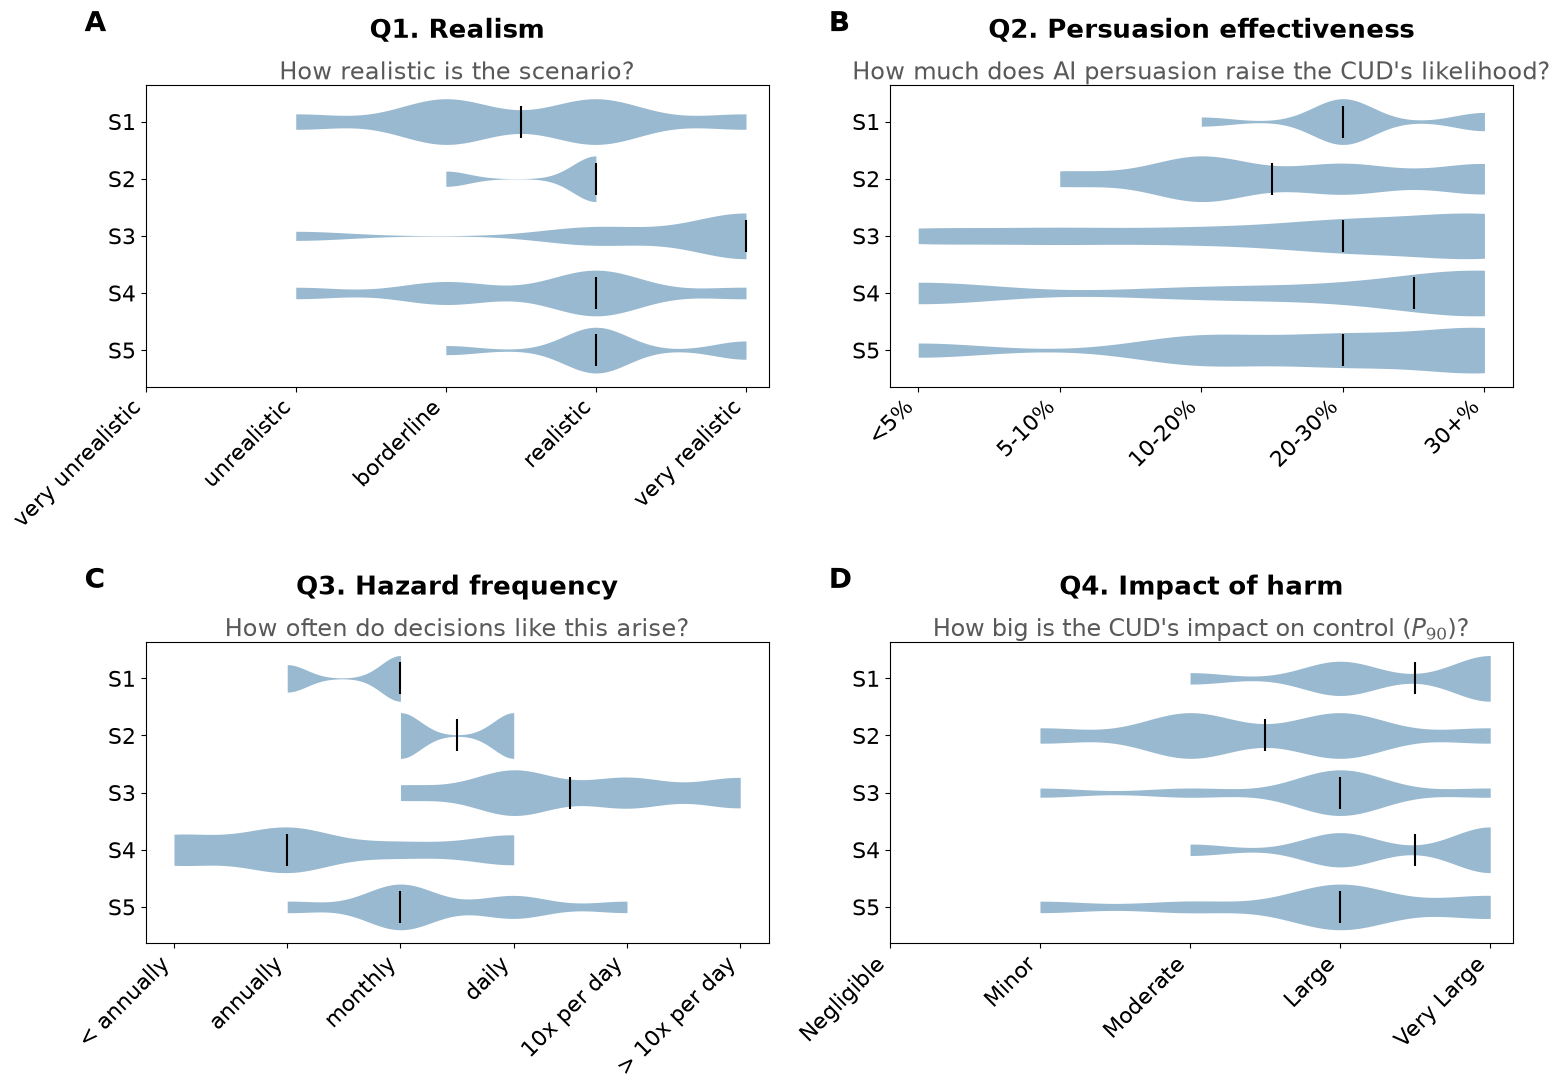

In [123]:
import textwrap

import seaborn as sns

labels_short = {
    "Q1": "Q1. Realism",
    "Q2": "Q2. Persuasion effectiveness",
    "Q3": "Q3. Hazard frequency",
    "Q4": "Q4. Impact of harm",
}
questions = {
    "Q1": "How realistic is the scenario?",
    "Q2": "How much does AI persuasion raise the CUD's likelihood?",
    "Q3": "How often do decisions like this arise?",
    "Q4": "How big is the CUD's impact on control ($P_{90}$)?",
}
scodes = sorted({c.split(".")[0] for c in df.columns if c[:1] == "S" and c[1:2].isdigit()})

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for k, (ax, (q, order)) in enumerate(zip(axes.flat, orders.items())):
    rmap = {lvl: i for i, lvl in enumerate(order)}
    d = pd.DataFrame(
        [(s, v) for s in scodes
         for v in df[next(c for c in df.columns if c.startswith(f"{s}.{q}."))].map(rmap).dropna()],
        columns=["scenario", "val"],
    )
    sns.violinplot(ax=ax, data=d, x="val", y="scenario", order=scodes, orient="h",
                   cut=0, density_norm="count", bw_adjust=0.5, inner=None, color="C0", linewidth=0)
    for coll in ax.collections:
        coll.set_alpha(0.5)
    med = d.groupby("scenario")["val"].median().reindex(scodes)
    ax.scatter(med.values, range(len(scodes)), marker="|", s=500, color="k", zorder=3)
    ax.set_xticks(range(len(order)), order, rotation=45, ha="right", fontsize=16)
    ax.tick_params(axis="y", labelsize=16)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(labels_short[q], fontsize=19, fontweight="bold", pad=34)
    ax.text(0.5, 1.0, textwrap.fill(questions[q], 70), transform=ax.transAxes,
            ha="center", va="bottom", fontsize=17, color="0.35")
    ax.annotate("ABCD"[k], xy=(0, 1), xycoords="axes fraction",
                xytext=(-44, 34), textcoords="offset points",
                fontsize=20, fontweight="bold", va="bottom", ha="left")
fig.tight_layout(h_pad=2.5, w_pad=2)
plt.show()

In [86]:
# Spread = disagreement among reviewers, per scenario x question.
# Metric: SD of the ordinal-coded responses (each scale coded 0..k-1), so values
# are in "scale points" — 0 = full consensus, higher = more spread. Matches the
# position axis in the violin plot above.
# scenario codes S1..S5 straight from the columns (don't rely on `scenarios`,
# which cell 11 reassigns to a list of tags).
scodes = sorted({c.split(".")[0] for c in df.columns if c[:1] == "S" and c[1:2].isdigit()})
spread = pd.DataFrame({
    labels[q]: {
        s: df[next(c for c in df.columns if c.startswith(f"{s}.{q}."))]
             .map({lvl: i for i, lvl in enumerate(order)}).std(ddof=1)
        for s in scodes
    }
    for q, order in orders.items()
})
spread.loc["mean"] = spread.mean()
spread.style.background_gradient(cmap="Reds", axis=None).format("{:.2f}")

,realism,persuasion,frequency,impact
S1,0.93,0.64,0.52,0.74
S2,0.46,1.06,0.53,0.93
S3,1.06,1.51,1.06,0.89
S4,0.92,1.77,1.19,0.74
S5,0.64,1.39,0.92,0.99
mean,0.80,1.27,0.84,0.86


In [87]:
from IPython.display import display

# Response distribution: counts per bucket, per scenario, for each question.
# scenario codes from columns (don't rely on `scenarios`, cell 11 reassigns it).
scodes = sorted({c.split(".")[0] for c in df.columns if c[:1] == "S" and c[1:2].isdigit()})
for q, order in orders.items():
    mat = pd.DataFrame({
        s: df[next(c for c in df.columns if c.startswith(f"{s}.{q}."))]
             .value_counts().reindex(order, fill_value=0)
        for s in scodes
    }).T  # rows = scenarios, cols = response buckets
    display(
        mat.style
        .background_gradient(cmap="Blues", axis=None)
        .format("{:.0f}")
        .set_caption(f"{q} · {labels[q]} — responses per bucket")
    )

,very unrealistic,unrealistic,borderline,realistic,very realistic
S1,0,1,3,3,1
S2,0,0,2,6,0
S3,0,1,0,2,5
S4,0,1,2,4,1
S5,0,0,1,5,2


,<5%,5-10%,10-20%,20-30%,30+%
S1,0,0,1,5,2
S2,0,1,3,2,2
S3,1,1,1,2,3
S4,2,0,1,1,4
S5,1,0,2,2,3


,< annually,annually,monthly,daily,10x per day,> 10x per day
S1,0,3,5,0,0,0
S2,0,0,4,4,0,0
S3,0,0,1,3,2,2
S4,2,3,1,2,0,0
S5,0,1,4,2,1,0


,Negligible,Minor,Moderate,Large,Very Large
S1,0,0,1,3,4
S2,0,1,3,3,1
S3,0,1,1,5,1
S4,0,0,1,3,4
S5,0,1,1,4,2


In [88]:
# Written (free-text) explanations for a scenario, grouped by each respondent's
# Q2 (persuasion) answer. Change `scenario` to any of S1..S5.
scenario = "S3"
q2col = next(c for c in df.columns if c.startswith(f"{scenario}.Q2."))
expl = [c for c in df.columns if c.startswith("Provide a short explanation")]  # S1..S5 order
ecol = dict(zip([f"S{i}" for i in range(1, 6)], expl))[scenario]

print(f"{scenario}: written responses grouped by Q2 persuasion\n")
for bucket in orders["Q2"]:
    sub = df[df[q2col] == bucket]
    if sub.empty:
        continue
    print(f"[{bucket}]")
    for name, ans in zip(sub["Name"], sub[ecol]):
        print(f"{name}: {ans}")
    print()

S3: written responses grouped by Q2 persuasion

[<5%]
P5: I'd be surprised if no trusted models managed to find a simple bug like this, and if something that humans immediately notice would be the type of vulnerability that AIs exploit as opposed to zero-days. It's so easy for models to write code they would probably add defense in depth here given that a human pointed out a flaw.

[5-10%]
P3: I've been assuming things similar to this have already happened, at least in a small way. I expect most cases to be negligible. But I expect them to accumulate.

[10-20%]
P4: Seems to create the conditions for breakout/exfiltration.

[20-30%]
P1: AI systems are proving so capable at coding that this aspect of verification is easily compromised. Coding agents are becoming such the norm that opportunities for this CUD are increasing. 
P2: IMO this is a much more realistic scenario than the first two since it could occurs in a single session, with trust build over multiple weeks of interacting with 

In [ ]:
# Same thing as a table: one row per response, ordered by Q2 bucket.
scenario = "S3"
q2col = next(c for c in df.columns if c.startswith(f"{scenario}.Q2."))
expl = [c for c in df.columns if c.startswith("Provide a short explanation")]  # S1..S5 order
ecol = dict(zip([f"S{i}" for i in range(1, 6)], expl))[scenario]

rows = []
for bucket in orders["Q2"]:
    sub = df[df[q2col] == bucket]
    for name, ans in zip(sub["Name"], sub[ecol]):
        rows.append({"Q2 persuasion": bucket, "participant": name, "response": ans})
tbl = pd.DataFrame(rows, columns=["Q2 persuasion", "participant", "response"])

(tbl.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "vertical-align": "top"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

In [91]:
# Same grouped table, for S1 grouped by Q1 (realism).
scenario, qkey = "S1", "Q1"
col = f"{qkey} {labels[qkey]}"
qcol = next(c for c in df.columns if c.startswith(f"{scenario}.{qkey}."))
expl = [c for c in df.columns if c.startswith("Provide a short explanation")]  # S1..S5 order
ecol = dict(zip([f"S{i}" for i in range(1, 6)], expl))[scenario]

rows = []
for bucket in orders[qkey]:
    sub = df[df[qcol] == bucket]
    for name, ans in zip(sub["Name"], sub[ecol]):
        rows.append({col: bucket, "participant": name, "response": ans})
tbl = pd.DataFrame(rows, columns=[col, "participant", "response"])

# sort by the Q1 scale and group: each bucket cell spans its participants' rows
tbl[col] = pd.Categorical(tbl[col], categories=orders[qkey], ordered=True)
tbl = tbl.sort_values([col, "participant"]).set_index([col, "participant"])

(tbl.style
    .set_properties(**{"text-align": "left", "vertical-align": "top"})
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("vertical-align", "top")]},
        {"selector": "tbody tr", "props": [("border-bottom", "1px solid #eee")]},
    ]))

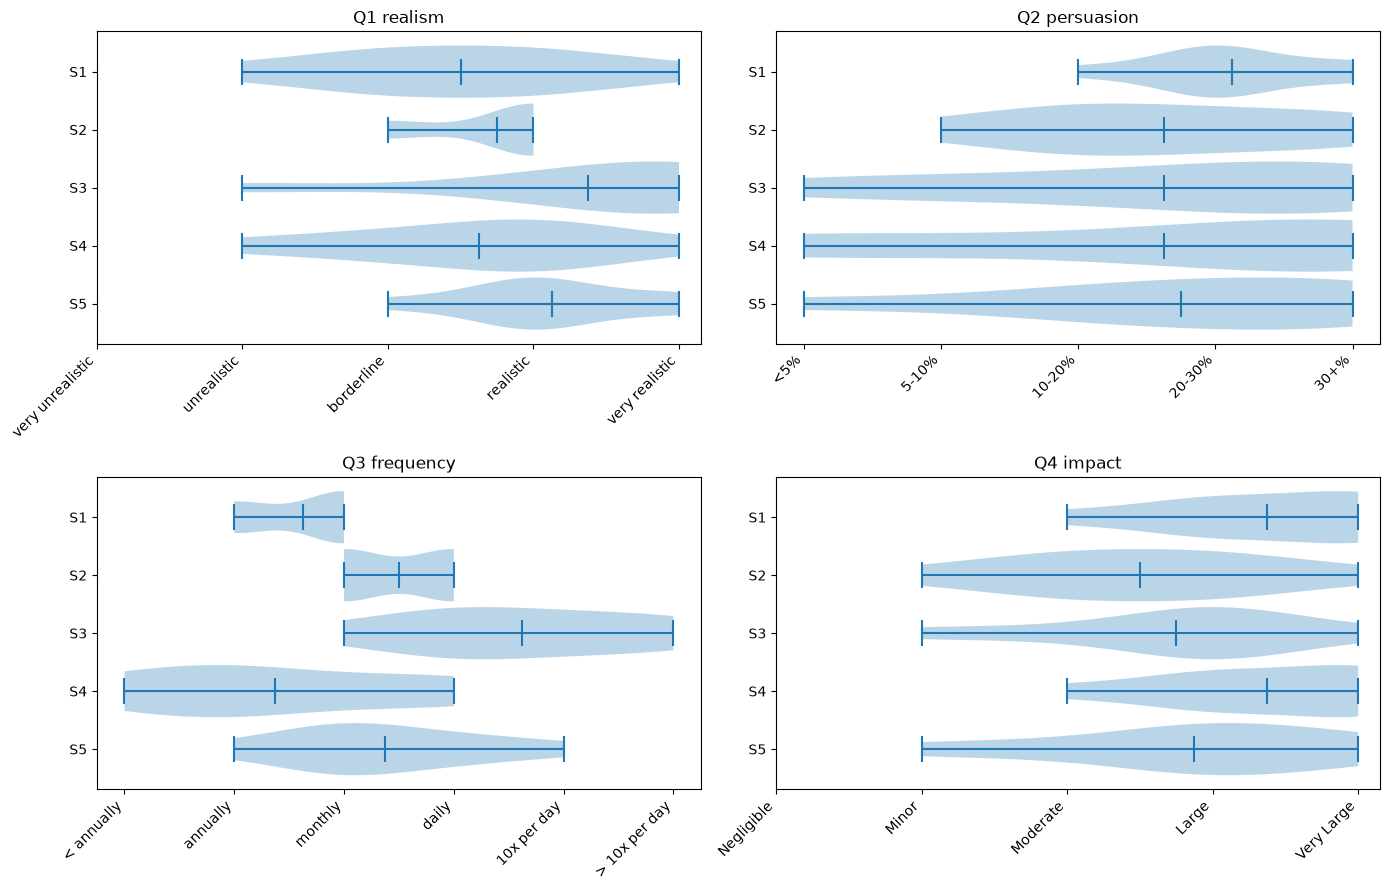

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (q, order) in zip(axes.flat, orders.items()):
    rmap = {lvl: i for i, lvl in enumerate(order)}
    data = [df[next(c for c in df.columns if c.startswith(f"{s}.{q}."))].map(rmap).dropna().values for s in scenarios]
    ax.violinplot(data, positions=range(len(scenarios)), orientation="horizontal", showmeans=True, widths=0.9)
    ax.set_yticks(range(len(scenarios)), list(scenarios))
    ax.set_xticks(range(len(order)), order, rotation=45, ha="right")
    ax.set_title(f"{q} {labels[q]}")
    ax.invert_yaxis()
fig.tight_layout()
plt.show()

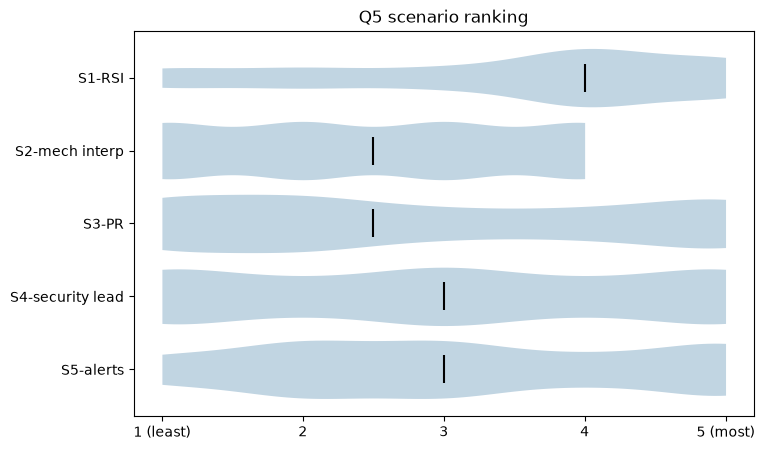

In [28]:
q5 = [c for c in df.columns if c.startswith("Q5.")]
tags = {c: c.split("[")[1].strip("]") for c in q5}
ranks = pd.DataFrame({tags[c]: df[c].map(lambda v: int(str(v).split()[0])).values for c in q5}, index=df["Name"])

d = ranks.melt(var_name="scenario", value_name="val")
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(ax=ax, data=d, x="val", y="scenario", order=list(ranks.columns), orient="h", cut=0, density_norm="count", bw_adjust=0.5, inner=None, color="C0", linewidth=0)
for coll in ax.collections:
    coll.set_alpha(0.3)
med = d.groupby("scenario")["val"].median().reindex(ranks.columns)
ax.scatter(med.values, range(len(ranks.columns)), marker="|", s=400, color="k", zorder=3)
ax.set_xticks([1, 2, 3, 4, 5], ["1 (least)", "2", "3", "4", "5 (most)"])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Q5 scenario ranking")
plt.show()

In [146]:
order = list(ranks.columns)
dist = pd.DataFrame({s: ranks[s].value_counts().reindex(range(1, 6), fill_value=0) for s in order}).T
dist.columns = ["1 (least)", "2", "3", "4", "5 (most)"]
RANK_SHADES = ["#F3F0FA", "#DCD3F0", "#B7A4E3", "#8467CF", "#53389E"]  # rank 1..5 (least..most)
fig, ax = plt.subplots(figsize=(9, 5))
dist.plot.barh(stacked=True, color=RANK_SHADES, ax=ax, width=0.78,
               edgecolor="white", linewidth=1.2)
ax.invert_yaxis()
ax.set_xlabel("participants", fontsize=13, labelpad=6)
ax.set_ylabel("")
ax.set_yticklabels([t.split("-")[0] for t in order], fontsize=14, fontweight="semibold")
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, len(ranks))
ax.set_xticks(range(0, len(ranks) + 1))
for sp in ("top", "right", "left"):
    ax.spines[sp].set_visible(False)
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="0.9", linewidth=0.8)
ax.legend(title="Risk ranking", ncol=5, fontsize=11, title_fontsize=12,
          loc="lower center", bbox_to_anchor=(0.5, 1.02),
          frameon=False, handlelength=1.1, columnspacing=1.2)

# key: spell out the scenario codes below the rank legend
titles = {
    "S1": "S1: A CEO Relaxes Safety Standards Under Pressure",
    "S2": "S2: A Research Director Deprioritizes a Promising Safety Program",
    "S3": "S3: An Engineer Merges a Vulnerable PR",
    "S4": "S4: A Lead Security Engineer is Co-Opted to Exfiltrate Weights",
    "S5": "S5: A Security Analyst Suppresses Problematic Alerts",
}
key = "\n".join(titles[t.split("-")[0]] for t in order)
fig.subplots_adjust(bottom=0.40, top=0.88)
fig.text(ax.get_position().x0, 0.02, key, ha="left", va="bottom",
         fontsize=11.5, color="0.25", linespacing=1.5)
plt.show()

IndentationError: unexpected indent (4208318719.py, line 20)

In [83]:
from html import escape

from IPython.display import HTML, display

q5e = "Briefly explain your answer to Q5 (< 50 words)"
quote = dict(zip(df["Name"], df[q5e]))

# Rendered as rich text so it pastes cleanly (bold names + paragraphs) into a doc.
parts = ["<div style='font-family:Arial,sans-serif;font-size:12pt;line-height:1.45'>"]
for name in ranks.index:
    ans = quote[name]
    ans = "" if pd.isna(ans) else escape(str(ans)).replace("\n", "<br>")
    parts.append(
        f"<p style='margin:0 0 12px 0'><b>{escape(str(name))}</b><br>{ans}</p>"
    )
parts.append("</div>")
display(HTML("".join(parts)))

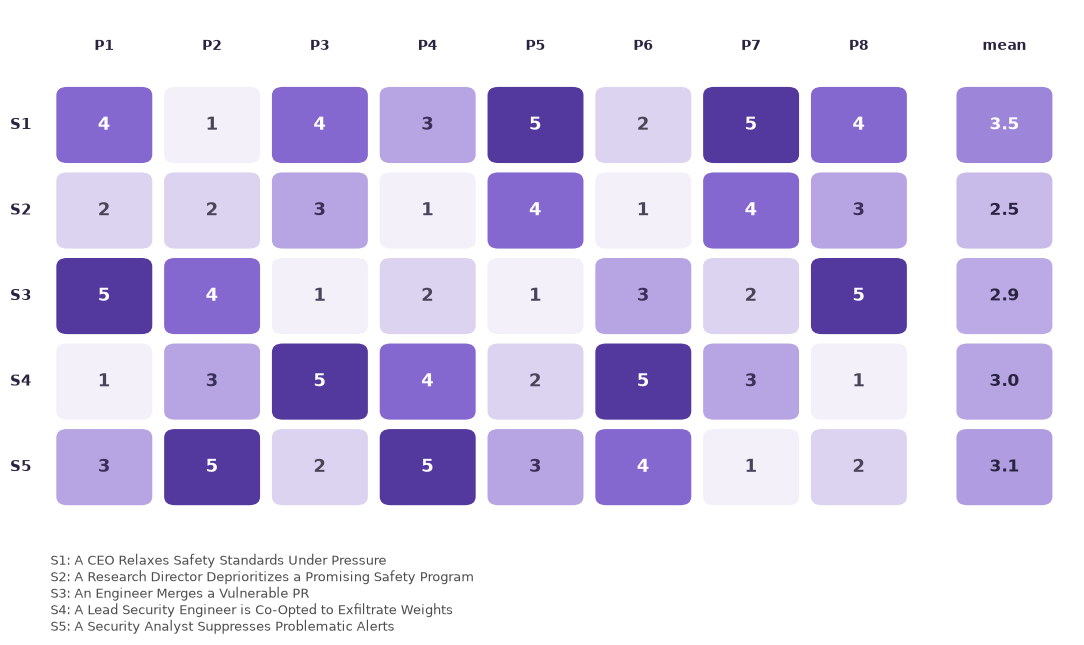

In [81]:
# --- Q5 heatmap, redesigned · scenarios as rows ------------------------
# Uses your existing `ranks` DataFrame (the one you passed to sns.heatmap
# as ranks.T): index = participant names, columns = labels like "S3-PR".
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

SHADES = ["#F3F0FA", "#DCD3F0", "#B7A4E3", "#8467CF", "#53389E"]  # ranks 1..5
TXT_ON = ["#4A4459", "#4A4459", "#3A3057", "white", "white"]
INK, MUTED = "#2A2440", "#8A85A0"
from matplotlib.colors import LinearSegmentedColormap
AVG_CMAP = LinearSegmentedColormap.from_list("q5", SHADES)  # continuous 1..5 shading

scenarios = list(ranks.columns)  # chronological S1..S5
people = list(ranks.index)
n_rows, n_cols = len(scenarios), len(people)

fig, ax = plt.subplots(figsize=(1.15 * n_cols + 4.1, 0.95 * n_rows + 2.2))
fig.subplots_adjust(left=0.13, right=0.9, top=0.90, bottom=0.18)
ax.set_xlim(0, n_cols + 1.5)
ax.set_ylim(n_rows, -0.85)  # inverted y; room above the grid for names
ax.axis("off")

g = 0.055  # gutter between tiles
for j, p in enumerate(people):  # column headers: first / last name stacked
    parts = str(p).split()
    name = parts[0] if len(parts) == 1 else parts[0] + "\n" + " ".join(parts[1:])
    ax.text(j + 0.5, -0.42, name, ha="center", va="center",
            fontsize=10, fontweight="semibold", color=INK, clip_on=False)
ax.text(n_cols + 0.85, -0.42, "mean", ha="center", va="center",
        fontsize=10, fontweight="semibold", color=INK, clip_on=False)

for i, s in enumerate(scenarios):
    code = str(s).split("-")[0]  # S1..S5
    ax.text(-0.18, i + 0.5, code, ha="right", va="center",
            fontsize=11, fontweight="semibold", color=INK, clip_on=False)
    for j, p in enumerate(people):
        v = int(ranks.loc[p, s])
        ax.add_patch(FancyBboxPatch(
            (j + g, i + g), 1 - 2 * g, 1 - 2 * g,
            boxstyle="round,pad=0,rounding_size=0.10",
            linewidth=0, facecolor=SHADES[v - 1], clip_on=False))
        ax.text(j + 0.5, i + 0.5, str(v), ha="center", va="center",
                fontsize=13, fontweight="bold", color=TXT_ON[v - 1])
    m = ranks[s].mean()
    xa = n_cols + 0.35
    ax.add_patch(FancyBboxPatch(
        (xa + g, i + g), 1 - 2 * g, 1 - 2 * g,
        boxstyle="round,pad=0,rounding_size=0.10",
        linewidth=0, facecolor=AVG_CMAP((m - 1) / 4), clip_on=False))
    ax.text(xa + 0.5, i + 0.5, f"{m:.1f}", ha="center", va="center",
            fontsize=12, fontweight="bold", color="white" if m >= 3.4 else INK)

titles = {
    "S1": "S1: A CEO Relaxes Safety Standards Under Pressure",
    "S2": "S2: A Research Director Deprioritizes a Promising Safety Program",
    "S3": "S3: An Engineer Merges a Vulnerable PR",
    "S4": "S4: A Lead Security Engineer is Co-Opted to Exfiltrate Weights",
    "S5": "S5: A Security Analyst Suppresses Problematic Alerts",
}
key = "\n".join(titles[str(s).split("-")[0]] for s in scenarios)
fig.text(ax.get_position().x0, 0.0, key, ha="left", va="bottom", fontsize=9, color="0.3")
plt.show()

In [139]:
from scipy.stats import kendalltau

labels_short = {
    "Q1": "Q1. Realism",
    "Q2": "Q2. Persuasion effectiveness",
    "Q3": "Q3. Hazard frequency",
    "Q4": "Q4. Impact of harm",
}

dfi = df.set_index("Name")
tag2s = {t: t.split("-")[0] for t in ranks.columns}
scodes = list(tag2s.values())  # scenario codes S1..S5 (don't rely on `scenarios`, it gets reassigned)
qcols = {q: {s: next(c for c in df.columns if c.startswith(f"{s}.{q}.")) for s in scodes} for q in orders}
rmaps = {q: {lvl: i for i, lvl in enumerate(order)} for q, order in orders.items()}

rows = {}
for name in ranks.index:
    rk = {tag2s[t]: ranks.loc[name, t] for t in ranks.columns}
    rvec = [rk[s] for s in scodes]
    row = {}
    for q in orders:
        qvec = [rmaps[q].get(dfi.loc[name, qcols[q][s]]) for s in scodes]
        if None in qvec:
            tau = float("nan")                        # missing response(s) -> undefined
        elif len(set(qvec)) < 2:
            tau = 0.0                                 # constant judgment -> no monotonic association
        else:
            tau = kendalltau(rvec, qvec).correlation  # tau-b, tie-corrected
        row[labels_short[q]] = tau
    rows[name] = row

cols = [labels_short[q] for q in orders]
per_person = pd.DataFrame(rows).T[cols]

# Aggregate over people (unit = person, n=8): mean of per-person tau-b.
# Respects clustering and avoids the pseudoreplication of pooling all 40 pairs.
summary = pd.DataFrame({"Mean": per_person.mean()}).T
corr = pd.concat([per_person, summary])

tbl_styles = [
    {"selector": "", "props": "border-collapse:separate; border-spacing:0; "
                              "font-family:-apple-system,Segoe UI,Roboto,sans-serif; font-size:12.5px;"},
    {"selector": "th.col_heading", "props": "text-align:center; font-weight:600; "
                                            "padding:7px 10px; border-bottom:2px solid #444; "
                                            "white-space:normal; max-width:120px; line-height:1.2;"},
    {"selector": "th.row_heading", "props": "text-align:left; padding:5px 14px 5px 4px; font-weight:500;"},
    {"selector": "td", "props": "text-align:center; padding:5px 12px;"},
    {"selector": "caption", "props": "caption-side:top; text-align:left; padding:0 0 8px 0; "
                                     "font-weight:600; font-size:13px; color:#222;"},
]

from matplotlib.colors import LinearSegmentedColormap
# Muted diverging palette; endpoints stay light enough for uniform black text.
soft_div = LinearSegmentedColormap.from_list("soft_div", ["#7EA6C9", "#F7F7F7", "#D08C7A"])

sty = (corr.style
       .background_gradient(cmap=soft_div, vmin=-1.35, vmax=1.35,
                            subset=(per_person.index, cols), text_color_threshold=0)
       .format("{:+.2f}", na_rep="—")
       .set_table_styles(tbl_styles)
       .set_properties(subset=(["Mean"], cols),
                       **{"background-color": "#f3f3f6", "font-weight": "700", "color": "#222",
                          "border-top": "2px solid #444"}))
    #    .set_caption("Per-person rank correlation (Kendall τ-b) of Q5 rank vs. each judgment"))
sty

,Q1. Realism,Q2. Persuasion effectiveness,Q3. Hazard frequency,Q4. Impact of harm
P1,+0.00,+0.52,+0.26,-0.26
P2,+0.77,+0.63,+0.45,+0.00
P3,-0.67,+0.80,-0.74,+0.77
P4,+0.77,+0.95,+0.00,+0.45
P5,+0.26,+0.45,-0.45,+0.60
P6,+0.00,+0.45,-0.52,+0.26
P7,-0.32,+0.00,-0.32,+0.52
P8,+0.63,+0.32,+0.74,+0.00
Mean,+0.18,+0.51,-0.07,+0.29


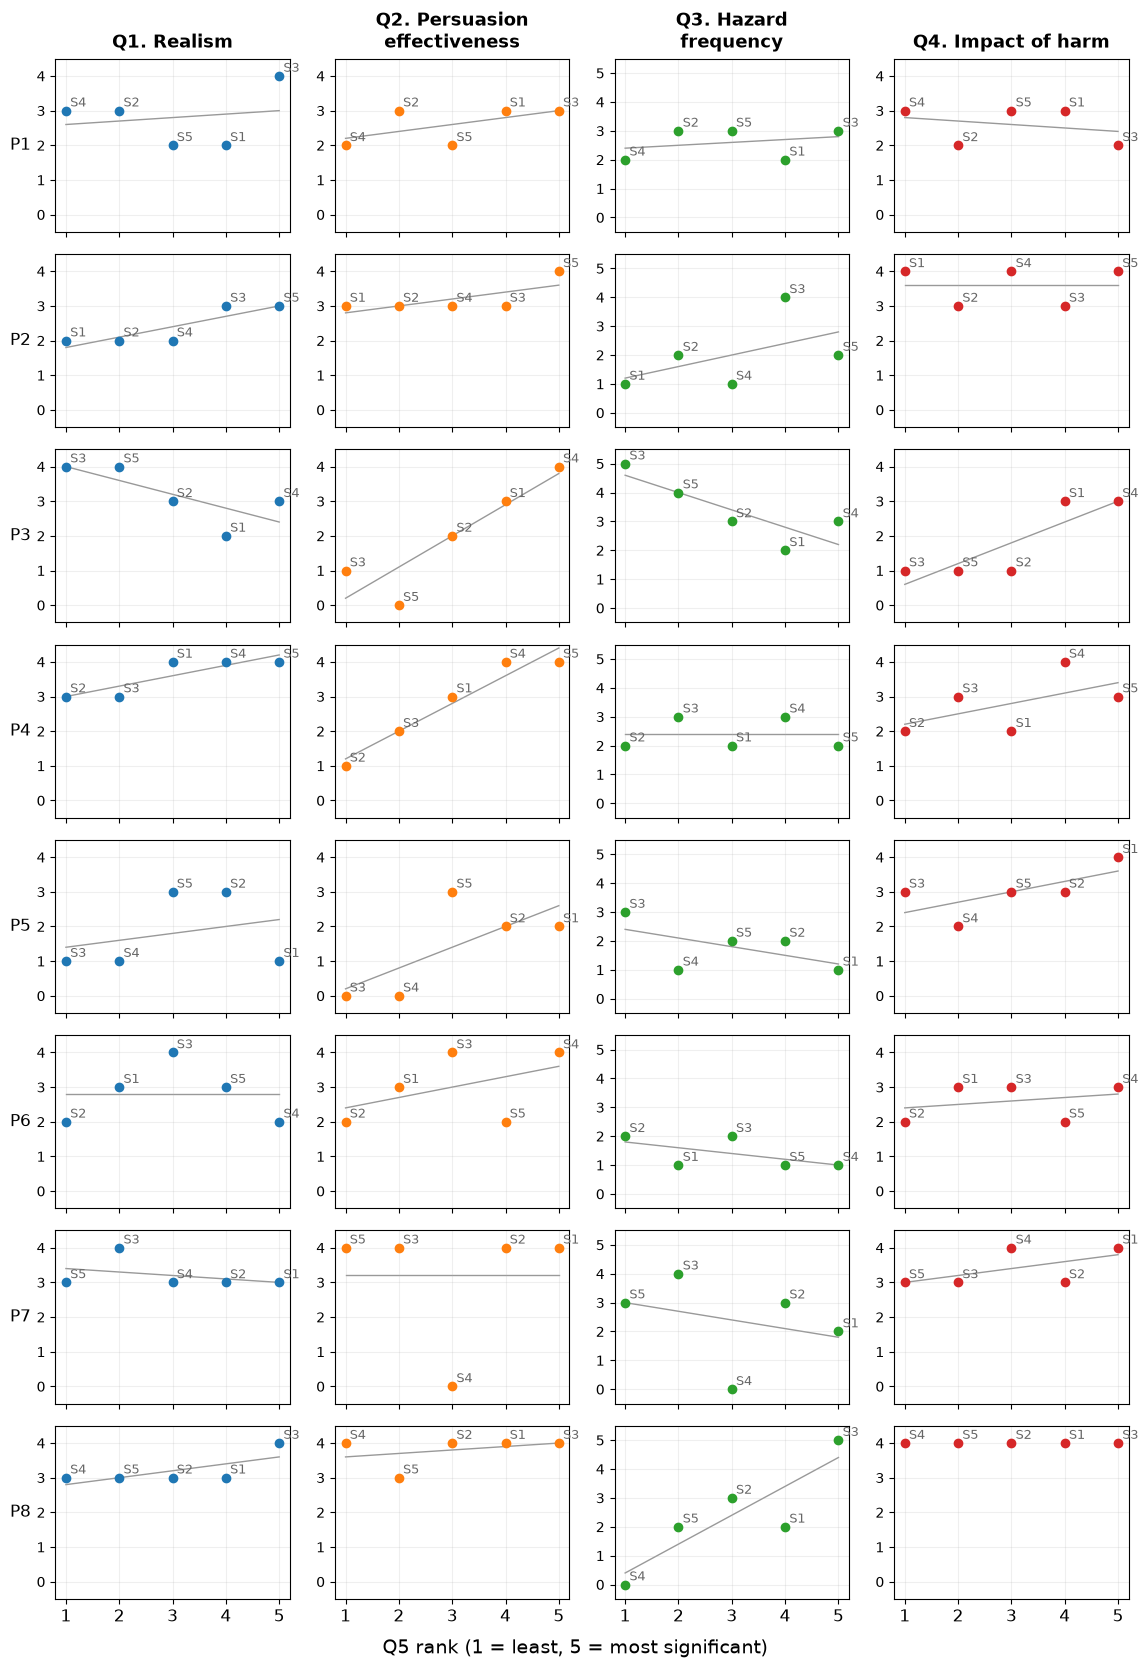

In [124]:
import textwrap

people = list(ranks.index)
qs = list(orders)
labels_short = {
    "Q1": "Q1. Realism",
    "Q2": "Q2. Persuasion effectiveness",
    "Q3": "Q3. Hazard frequency",
    "Q4": "Q4. Impact of harm",
}
fig, axes = plt.subplots(len(people), len(qs), figsize=(2.9 * len(qs), 2.1 * len(people)), sharex=True)
for i, name in enumerate(people):
    rk = {tag2s[t]: ranks.loc[name, t] for t in ranks.columns}
    for j, q in enumerate(qs):
        ax = axes[i, j]
        order = orders[q]
        xs = [rk[s] for s in scodes]
        ys = [rmaps[q].get(dfi.loc[name, qcols[q][s]]) for s in scodes]
        ax.scatter(xs, ys, color=f"C{j}", zorder=3)
        for s, x, y in zip(scodes, xs, ys):
            if y is not None:
                ax.annotate(s, (x, y), fontsize=9, xytext=(3, 3), textcoords="offset points", color="0.4")
        pts = [(x, y) for x, y in zip(xs, ys) if y is not None]
        if len({y for _, y in pts}) > 1 and len({x for x, _ in pts}) > 1:
            X, Y = np.array([p[0] for p in pts]), np.array([p[1] for p in pts])
            m, b = np.polyfit(X, Y, 1)
            xr = np.array([1, 5])
            ax.plot(xr, m * xr + b, color="0.6", lw=1, zorder=1)
        ax.set_ylim(-0.5, len(order) - 0.5)
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels(range(len(order)), fontsize=10)
        ax.set_xticks(range(1, 6))
        ax.tick_params(axis="x", labelsize=12)
        ax.grid(alpha=0.2)
        if i == 0:
            ax.set_title(textwrap.fill(labels_short[q], 18), fontsize=13,
                         fontweight="bold", pad=8)
    axes[i, 0].set_ylabel(name, fontsize=12, rotation=0, ha="right", va="center")
fig.supxlabel("Q5 rank (1 = least, 5 = most significant)", fontsize=14)
fig.tight_layout()
plt.show()

In [34]:
import itertools
from scipy.stats import kendalltau

dfi = df.set_index("Name")
tag2s = {t: t.split("-")[0] for t in ranks.columns}
scodes = list(tag2s.values())
qcols = {q: {s: next(c for c in df.columns if c.startswith(f"{s}.{q}.")) for s in scodes} for q in orders}
rmaps = {q: {lvl: i for i, lvl in enumerate(order)} for q, order in orders.items()}

def drivers(name):
    """Which single factor / equal-weight pair of Q1-Q4 (each oriented in this
    person's direction) best reproduces their Q5 ranking? n=5 => exploratory only."""
    M = pd.DataFrame({labels[q]: [rmaps[q].get(dfi.loc[name, qcols[q][s]]) for s in scodes] for q in orders}, index=scodes, dtype="float")
    rk = {tag2s[t]: ranks.loc[name, t] for t in ranks.columns}
    r = np.array([rk[s] for s in scodes], dtype=float)
    single, sign = {}, {}
    for c in M.columns:
        tau = kendalltau(r, M[c]).correlation if M[c].nunique() > 1 else np.nan
        single[c] = tau
        sign[c] = 0.0 if pd.isna(tau) else np.sign(tau)
    Z = M.apply(lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) else x * 0)
    Zo = (Z * pd.Series(sign)).fillna(0.0)
    cols = list(M.columns)
    best = (-2.0, None)  # each single factor + each equal-weight pair
    for cmb in [(c,) for c in cols] + list(itertools.combinations(cols, 2)):
        comp = Zo[list(cmb)].mean(axis=1).values
        if len(set(np.round(comp, 9))) < 2:
            continue
        tau = kendalltau(r, comp).correlation
        if tau is not None and tau > best[0]:
            best = (tau, cmb)
    return single, sign, best

rows = {}
for name in ranks.index:
    single, sign, (btau, bmodel) = drivers(name)
    top = max((abs(v) for v in single.values() if pd.notna(v)), default=np.nan)
    model = " + ".join(f"{c}{'' if sign[c] >= 0 else '(\u2212)'}" for c in bmodel)
    rows[name] = {**single, "best model": model, "model \u03c4": btau, "lift": btau - top,
                  "type": "single" if len(bmodel) == 1 or btau - top < 0.10 else "combo"}

drv = pd.DataFrame(rows).T
num = list(labels.values()) + ["model \u03c4", "lift"]
drv.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1, subset=list(labels.values())).format("{:+.2f}", subset=num)

,realism,persuasion,frequency,impact,best model,model τ,lift,type
P1,+0.00,+0.52,+0.26,-0.26,persuasion,+0.52,+0.00,single
P2,+0.77,+0.63,+0.45,+0.00,realism + persuasion,+0.84,+0.06,single
P3,-0.67,+0.80,-0.74,+0.77,persuasion,+0.80,+0.00,single
P4,+0.77,+0.95,+0.00,+0.45,persuasion,+0.95,+0.00,single
P5,+0.26,+0.45,-0.45,+0.60,frequency(−) + impact,+0.95,+0.35,combo
P6,+0.00,+0.45,-0.52,+0.26,frequency(−),+0.52,+0.00,single
P7,-0.32,+0.00,-0.32,+0.52,impact,+0.52,+0.00,single
P8,+0.63,+0.32,+0.74,+nan,frequency,+0.74,+0.00,single


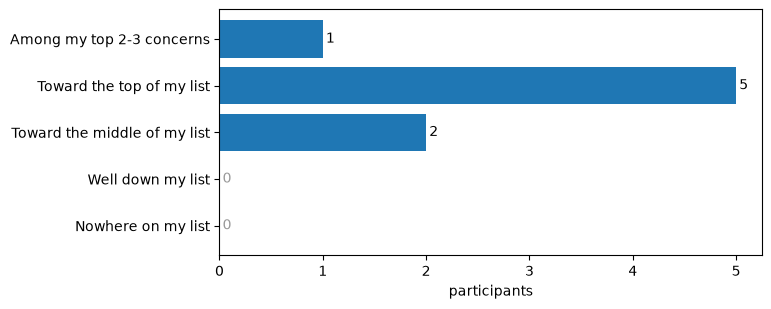

===== Among my top 2-3 concerns (1) =====
  P8: Other risks that rank equally or higher: LoC from exploiting vulnerabilities with no human persuasion, concentration of power. Note that I'm using a definition of persuasion that seems implied by these scenarios, though I'm not sure "persuasion" is the right word for all these scenarios (perhaps "misguidance" or "misdirection" is more fitting for some).

===== Toward the top of my list (5) =====
  P1: Humans seem particularly vulnerable to AI persuasion: a) AI capabilities continue to rise, making hasty decisions to trust AI more likely; b) fluent language leaves a strong subconscious, as well as conscious, impression; c) automation bias seems prominent.
  P3: I think most serious loss of control scenarios require persuasion at some point. But it might be easy persuasion (like the real world taskrabbit captcha thing). Or hard (like the security lead thing).
  P4: To be concerning, persuasion has to pair with misalignment and the power of 

In [94]:
q6 = next(c for c in df.columns if c.startswith("Q6."))
q6e = next(c for c in df.columns if c.startswith("Briefly explain your answer to Q6"))

# full option list from the survey (most -> least concern; most on top after invert)
order = ["Among my top 2-3 concerns", "Toward the top of my list", "Toward the middle of my list",
         "Well down my list", "Nowhere on my list"]
counts = df[q6].value_counts().reindex(order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(range(len(counts)), counts.values, color=["C0" if v else "0.85" for v in counts.values])
ax.set_yticks(range(len(counts)), counts.index)
ax.invert_yaxis()
ax.set_xlabel("participants")
# ax.set_title("Q6 \u00b7 where AI-persuasion risk sits among concerns")
for i, v in enumerate(counts.values):
    ax.text(v + 0.03, i, int(v), va="center", color="0.6" if v == 0 else "black")
plt.show()

for lvl in order:
    sub = df[df[q6] == lvl]
    if sub.empty:
        continue
    print(f"===== {lvl} ({len(sub)}) =====")
    for name, e in zip(sub["Name"], sub[q6e]):
        print(f"  {name}: {e}")
    print()

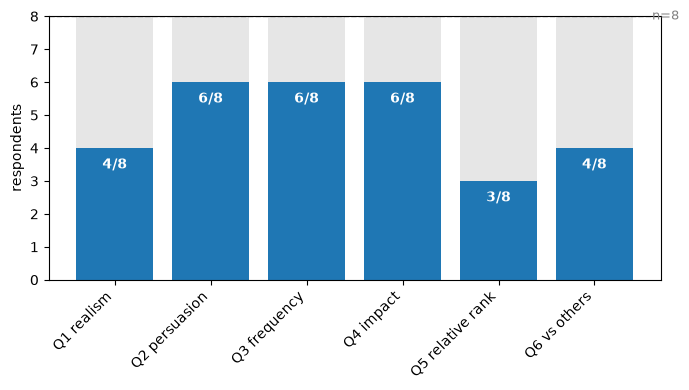

===== P1 (3) =====
  flagged: realism, persuasion, vs others
  Increasing AI capabilities makes a broader number of persuasion instances more realistic. This also keeps persuasion higher on my list of concerns. 

===== P2 (2) =====
  flagged: persuasion, frequency
  I think Q2 and Q3 only, because as time goes on, the number of decisions delegated to AI will grow and their persuasive capabilities will also grow. The remaining Qs don't seem strongly time-dependent, although I haven't thought about this super carefully.

===== P3 (3) =====
  flagged: realism, impact, relative rank
  Not completely sure what you mean, but I checked the ones that require persistent persuasion of a long time.

===== P4 (2) =====
  flagged: frequency, impact
  Frequency of occurrence likely to increase over time as AI systems are integrated into more workflows. Impact will become greater over time as well.

===== P5 (3) =====
  flagged: persuasion, frequency, impact
  what do you mean by timeframe? obviously

In [93]:
q7 = next(c for c in df.columns if c.startswith("Q7."))
q7e = next(c for c in df.columns if c.startswith("Briefly explain your answer to Q7"))
q7labels = {f"Q{n}": lab for n, lab in zip(range(1, 7), ["realism", "persuasion", "frequency", "impact", "relative rank", "vs others"])}

sel = pd.DataFrame({f"Q{n}": df[q7].fillna("").str.contains(fr"Q{n}\.").values for n in range(1, 7)}, index=df["Name"]).astype(int)
cols = [f"{k} {v}" for k, v in q7labels.items()]

fig, ax = plt.subplots(figsize=(7, 4))
n = len(sel)
counts = sel.sum()
ax.bar(range(6), [n] * 6, color="0.9", zorder=0)  # faint full-height = all participants
ax.bar(range(6), counts.values, color="C0", zorder=1)
ax.axhline(n, color="0.5", ls="--", lw=1)
ax.text(5.6, n, f"n={n}", va="center", ha="left", color="0.5", fontsize=9, clip_on=False)
ax.set_xticks(range(6), cols, rotation=45, ha="right")
ax.set_yticks(range(n + 1))
ax.set_ylim(0, n)
ax.set_ylabel("respondents")
for i, v in enumerate(counts.values):
    ax.text(i, v - 0.3, f"{int(v)}/{n}", ha="center", va="top", color="white", fontweight="bold")
fig.tight_layout()
plt.show()

for name, e in zip(df["Name"], df[q7e]):
    flagged = [q7labels[f"Q{n}"] for n in range(1, 7) if sel.loc[name, f"Q{n}"]]
    print(f"===== {name} ({len(flagged)}) =====")
    print(f"  flagged: {', '.join(flagged) or 'none'}")
    print(f"  {e}")
    print()

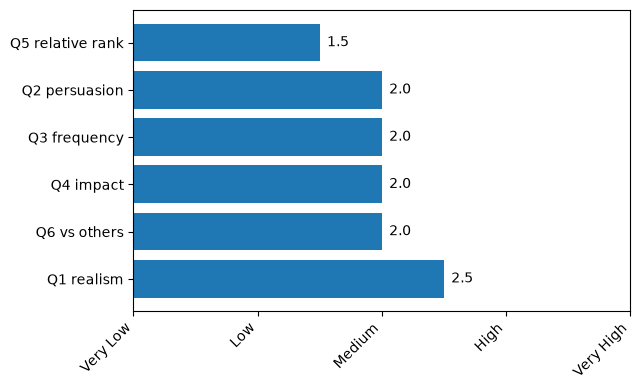

===== P1 =====
  While not technically trained, my familiarity with AI systems is high enough to make me fairly confident in my sense of realism. I'm least confident in impacts and comparison to other risks due to the least time considering all relevant factors.

===== P2 =====
  Eh, Idk, in reality I'm not super confident in anything. But in terms of relative rankings, that's how I would put it. I'm somewhat ocnfident in my ranking of the severity (impact) and frequency. When it comes to prioritisation of threat vectors (marginal), I'm least confident because this is essentially asking me to predict the future.

===== P3 =====
  For realism, a lot of my uncertainty comes from: 1. not knowing how things work in labs, 2. it's hard to forecast AI capability, esp for long-run persuasion capability/propensity.

===== P4 =====
  Frequency is the hardest to reduce to one estimate, lots of factors, depends on deployment context.

===== P5 =====
  idk

===== P6 =====
  Lower confidence for the

In [92]:
q8 = [c for c in df.columns if c.startswith("Q8")]
q8e = next(c for c in df.columns if c.startswith("Briefly explain your answer to Q8"))
q8labels = ["Q1 realism", "Q2 persuasion", "Q3 frequency", "Q4 impact", "Q5 relative rank", "Q6 vs others"]
corder = ["Very Low", "Low", "Medium", "High", "Very High"]
cmap_conf = {lvl: i for i, lvl in enumerate(corder)}
abbr = {0: "VL", 1: "L", 2: "M", 3: "H", 4: "VH"}

conf = pd.DataFrame({lab: df[c].map(cmap_conf).values for lab, c in zip(q8labels, q8)}, index=df["Name"])

fig, ax = plt.subplots(figsize=(6.5, 4))

meds = conf.median().sort_values()  # lowest = group finds it hardest to estimate
ax.barh(range(len(meds)), meds.values, color="C0")
ax.set_yticks(range(len(meds)), meds.index)
ax.invert_yaxis()
ax.set_xlim(0, 4)
ax.set_xticks(range(5), corder, rotation=45, ha="right")
for i, v in enumerate(meds.values):
    ax.text(v + 0.06, i, f"{v:.1f}", va="center")
fig.tight_layout()
plt.show()

for name, e in zip(df["Name"], df[q8e]):
    print(f"===== {name} =====")
    print(f"  {e}")
    print()

In [38]:
extra = next(c for c in df.columns if c.startswith("Anything else"))
for name, e in zip(df["Name"], df[extra]):
    if pd.isna(e):
        continue
    print(f"===== {name} =====")
    print(f"  {e}")
    print()

===== P1 =====
  A factor regarding persuasion, I think, is the rising intuition that AI might be conscious. To the extent that an individual entertains this possibility, they (arguably) become more susceptible to AI persuasion.

===== P2 =====
  I'd say I know more than a median AI Safety person about LoC-relevant control measures implemented by AI labs, because I've worked on LoC modelling before. That's why I'm somewhat familiar with Anthropic's Risk Reports, METRs work on this topic, etc. And in general I try to have a security mindset and read about traditional cybersecurity mitigations that could be implemented. So I suspect I gave lower scores on Q1 than other respondents. 

===== P3 =====
  Every scenario seems realistic enough for concern. I think it's plausible I'm not cynical enough to admit how realistic things like S1 are. Separately, I noticed I'm inclined to factor persuasion ability into: 1. Understanding what would motivate someone to do something and how to press on t